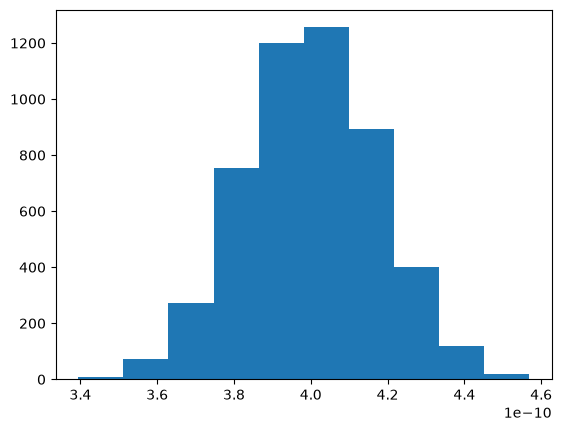

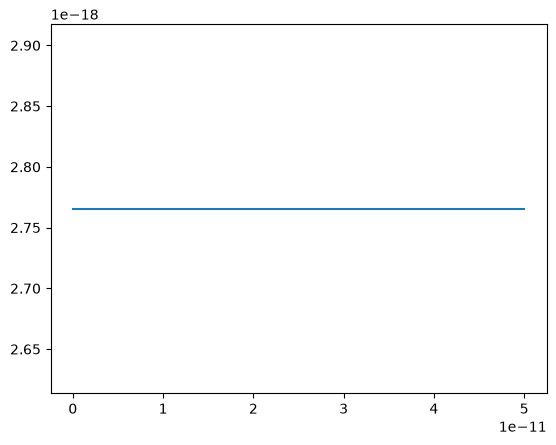

362.15241916109375


In [45]:
import numpy as np
import matplotlib.pyplot as plt

# PARAMETRES

n = 5000                # nombre d'atomes
dt = 5e-14              # pas de temps
sigma = 4e-10           # distance interatomique
L = n*sigma             # longueur de la chaîne
kB = 1.38e-23
epsilon = 400           # 400 K = profondeur du puits

k = 72*epsilon*kB/(sigma**2)   # constante de raideur

M = 57e-3
N_Avogadro = 6.022e23
m = M / N_Avogadro      # masse de l'atome en kg => 9.5e-26 kg

T = 400
v_moy = np.sqrt(kB*T/m) # vitesse moyenne des particules en m/s

C = []                  # liste contenant toutes matrices d'état
E = []                  # liste contenant toutes les énergies mécaniques au cours du temps


# FONCTIONS

def calcul_accelerations(A, X, k, m, sigma):
    '''On fait le calcul à partir du bilan des forces sur la chaîne d'atomes.'''
    A[0] = k/m * (X[1] - X[0] - sigma)              # a_0 = k/m * (x_1 - x_0 - sigma)
    A[1:-1] = k/m * (X[2:] - 2*X[1:-1] + X[:-2])    # a_i = k/m * (x_(i+1) - 2x_i + x_(i-1))
    A[-1] = k/m * (X[-2] - X[-1] + sigma)           # a_(N-1) = k/m * (x_(N-2) - x_(N-1) + sigma)

    return A


# ALGORITHME DE VERLET VITESSE
def verlet_vitesse(C, dt, k, m, sigma):
    '''On fait une itération de l'algorithme de Verlet Vitesse. En entrée, la matrice d'état à t ; en sortie, la matrice d'état à t+dt.'''
    X, V, A = C[1], C[2], C[3]
    V_ij = V + A * dt/2
    X_n = X + V_ij * dt
    A_n = calcul_accelerations(np.zeros(n), X_n, k, m, sigma)
    V_n = V_ij + A_n * dt/2

    # Matrice d'état à t + dt
    C_n = np.stack((N, X_n, V_n, A_n))

    return C_n


def E_m(C):
    X, V = C[1], C[2]
    E_c = 0
    E_p = 0
    for i in range(len(C)):
        E_c += 1/2 * m * V[i]**2
        # E_p = epsilon*(((sigma/V_n)**12) - 2*(sigma/V_n)**6) => potentiel de Lennard-Jones on le mettra parès
        E_p += 1/2 * k * X[i]**2
    E_m = E_c + E_p
    return E_m


def temperature_microcanonique(n, m, kB, V):
    T_sys = m / (n*kB)* np.sum(V**2)
    return T_sys


# INITIALISATION DES TABLEAUX

N = np.arange(n)                                        # tableau index
X = np.arange(0,L,sigma)                                # positions des particules
V = np.random.normal(loc=0, scale=v_moy, size=n)        # vitesse des particules
A = calcul_accelerations(np.zeros(n), X, k, m, sigma)   # accélération des particules

# Matrice d'état initiale
C_0 = np.stack((N,X,V,A))
C.append(C_0)
E.append(E_m(C_0))

# On fait tourner l'algorithme sur 1000 itérations
t = [0]
for i in range(1000):
    t.append(t[i]+dt)
    C_i = verlet_vitesse(C_0, dt, k, m, sigma)
    C.append(C_i)
    E.append(E_m(C_i))


'''
print("Etat initial C :")
print(C[0])
print("\nEtat après 1 pas de l'algorithme")
print(C[-1])'''

# On trace la distribution des distances interatomiques
C_n = C[-1]
X_n = C_n[1]
a = []
for i in range(len(X_n)-1):
    a.append(X_n[i+1] - X_n[i])
plt.hist(a)
plt.show()

# On trace l'évolution de l'énergie mécanique au cours du temps
plt.plot(t[1:],E[1:])
plt.show()

T_final = temperature_microcanonique(n, m, kB, C[-1][2])
print(T_final)